<a href="https://colab.research.google.com/github/chrishg23-jpg/HES-benchmark/blob/main/HES18Sim008.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import numpy as np

# --- Hyperparameters ---
dt = 0.01         # explicit step size
λ = None          # will be passed in per sweep
γ = 0.1           # sequestration/damping strength
clip = 5.0        # soft amplitude cap for stability

# --- Boundary-aware gradient (periodic) ---
def periodic_gradient(S):
    # central difference with wrap-around
    forward = np.roll(S, -1) - S
    backward = S - np.roll(S, 1)
    # symmetric estimate
    return 0.5 * (forward - backward)

# --- Optional Laplacian for smoother stabilization ---
def periodic_laplacian(S):
    return np.roll(S, -1) - 2.0 * S + np.roll(S, 1)

# --- Entropic term (normalized) ---
def entropic_gradient(S):
    g = periodic_gradient(S)
    norm = np.linalg.norm(g) + 1e-8
    return g / norm

# --- Holographic sequestration (mean-centering) ---
def holographic_sequestration(S):
    m = np.mean(S)
    return S - m  # penalize deviations; pushes toward mean-zero frame

# --- Stability-friendly update ---
def HES_update(S, λ, N):
    # core: S_{t+1} = S_t + dt[ λ * ∇H(S_t) + α * Laplacian(S_t) - (γ/N) * Φ(S_t) ]
    alpha = 0.1  # small smoothing via Laplacian
    dS = λ * entropic_gradient(S) + alpha * periodic_laplacian(S) - (γ / N) * holographic_sequestration(S)
    S_next = S + dt * dS
    # soft squash to prevent blow-up
    return np.tanh(S_next / clip) * clip


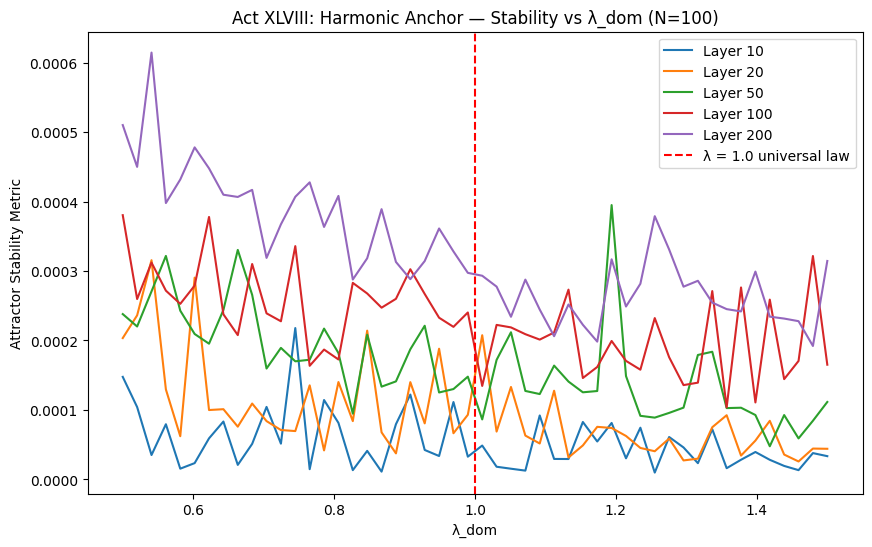

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# --- Parameters ---
N = 100
lambda_values = np.linspace(0.5, 1.5, 50)
steps = 2000
scale_layers = [10, 20, 50, 100, 200]

def simulate_layer(N, λ, steps, L):
    S = np.random.randn(L) * 0.1  # small init to avoid immediate blow-up
    stability = []
    for t in range(steps):
        S = HES_update(S, λ, N)
        if not np.isfinite(S).all():
            # early stop on instability
            break
        stability.append(np.var(S))
    return np.mean(stability) if stability else np.nan

results = {}
for L in scale_layers:
    results[L] = [simulate_layer(N, λ, steps, L) for λ in lambda_values]

plt.figure(figsize=(10,6))
for L in scale_layers:
    plt.plot(lambda_values, results[L], label=f"Layer {L}")
plt.axvline(1.0, color='red', linestyle='--', label="λ = 1.0 universal law")
plt.title("Act XLVIII: Harmonic Anchor — Stability vs λ_dom (N=100)")
plt.xlabel("λ_dom")
plt.ylabel("Attractor Stability Metric")
plt.legend()
plt.show()
